##IDE

In [ ]:
# ── CELL 1 dependancy
!pip install -q kaggle pandas numpy matplotlib seaborn scikit-learn \
               xgboost nfstream joblib scipy
!apt-get update -qq && apt-get install -y tshark -qq
!pip install -q pyshark scapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.0/195.0 kB 8.3 MB/s eta 0:00:00
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Preconfiguring packages ...
Selecting previously unselected package libpcap0.8:amd64.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../00-libpcap0.8_1.10.1-4ubuntu1.22.04.1_amd64.deb ...
Unpacking libpcap0.8:amd64 (1.10.1-4ubuntu1.22.04.1) ...
Selecting previously unselected package libbcg729-0:amd64.
Preparing to unpack .../01-libbcg729-0_1.1.1-2_amd64.deb ...
Unpacking libbcg729-0:amd64 (1.1.1-2) ...
Selecting previously unselected package liblua5.2-0:amd64.
Preparing to unpack .../02-liblua5.2-0_5.2.4-2_amd64.deb ...
Unpacking liblua5.2-0:amd64 (5.2.4-2) ...
Selecting previously unselected packag

In [ ]:
# ── CELL 2 liberary imports
import os, gc, warnings, logging, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import scipy.stats as stats
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Union

from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, precision_recall_curve,
)
from sklearn.calibration import calibration_curve
import xgboost as xgb
import pyshark
from scapy.all import rdpcap, IP, TCP, UDP

warnings.filterwarnings('ignore')
np.random.seed(42)

In [ ]:
# ── Logging
logging.basicConfig(level=logging.INFO, format='[%(levelname)s] %(message)s')
log = logging.getLogger('iot_ids')

ARTIFACTS_DIR = Path('/content/artifacts')
DATA_DIR      = Path('/content/cic_iiot_2025')
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

# featurs
TRAINING_FEATURE_COLS = [
    'network_time-delta_min',
    'network_time-delta_max',
    'network_time-delta_avg',
    'network_time-delta_std_deviation',
    'network_ip-length_avg',
    'network_ip-length_max',
    'network_ip-length_std_deviation',
    'network_interval-packets',
    'network_ttl_avg',
    'network_ttl_std_deviation',
    'network_window-size_avg',
    'network_window-size_max',
    'network_window-size_min',
    'network_window-size_std_deviation',
    'network_packets_all_count',
    'network_packets_dst_count',
    'network_packet-size_avg',
    'network_packet-size_min',
    'network_packet-size_std_deviation',
    'network_ports_all_count',
    'network_ports_src_count',
    'network_ports_dst_count',
    'network_tcp-flags_avg',
    'network_tcp-flags_std_deviation',
    'network_payload-length_avg',
]

def save(obj, name: str):
    path = ARTIFACTS_DIR / name
    if name.endswith('.npy'):
        np.save(path, obj)
    else:
        joblib.dump(obj, path)
    log.info(f"Saved {path}  ({path.stat().st_size/1024:.1f} KB)")

def load(name: str):
    path = ARTIFACTS_DIR / name
    if not path.exists():
        raise FileNotFoundError(f"Artifact not found: {path}")
    if name.endswith('.npy'):
        return np.load(path, allow_pickle=True)
    return joblib.load(path)

def check_artifacts(names: List[str]) -> bool:
    print(f"  {'Artifact':<35} {'Status':>8} {'Size':>10}")
    print(f"  {'─'*55}")
    ok = True
    for n in names:
        p = ARTIFACTS_DIR / n
        if p.exists():
            print(f"  {n:<35} {'exist':>8} {p.stat().st_size/1024:>8.1f} KB")
        else:
            print(f"  {n:<35} {'MISSING':>8}")
            ok = False
    return ok

In [ ]:

# ── CELL 3 file mount
from google.colab import files, drive

drive.mount('/content/drive')

DRIVE_DIR = Path('/content/drive/MyDrive/Final_MlPipeline_ciciiot2025_drive')
DRIVE_DIR.mkdir(parents=True, exist_ok=True)

print('Upload kaggle.json:')
uploaded = files.upload()
if 'kaggle.json' not in uploaded:
    raise FileNotFoundError('kaggle.json not found')

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets list --max-size 1 > /dev/null 2>&1 && echo "Kaggle auth OK" || echo "Kaggle auth FAILED"

DATA_PATH = DATA_DIR / 'combined_dataset.csv'
if not DATA_PATH.exists():
    print("Downloading dataset...")
    !kaggle datasets download muhammadirfangull/cic-iiot-2025
    !unzip -q cic-iiot-2025.zip -d {DATA_DIR}
    print("Download complete.")
else:
    print(f"Dataset already exists: {DATA_PATH}")

Mounted at /content/drive
Upload kaggle.json:


Saving kaggle.json to kaggle.json
Kaggle auth OK
Dataset URL: https://www.kaggle.com/datasets/muhammadirfangull/cic-iiot-2025
License(s): unknown
100% 524M/524M [00:15<00:00, 36.2MB/s]

Download complete.


In [ ]:
# ── CELL 4 ── Load and assesing the data
DATA_PATH = DATA_DIR / 'combined_dataset.csv'

df_raw = pd.read_csv(DATA_PATH)
print(f"Shape       : {df_raw.shape}")
print(f"Columns     : {len(df_raw.columns)}")
print(f"\nlabel1 dist :\n{df_raw['label1'].value_counts().to_string()}")
print(f"\nlabel2 dist :\n{df_raw['label2'].value_counts().to_string()}")
assert 'label1' in df_raw.columns, "Missing label1"
assert 'label2' in df_raw.columns, "Missing label2"
assert df_raw['label1'].isin(['benign','attack']).all(), \
    f"Unexpected label1 values: {df_raw['label1'].unique()}"
assert df_raw.shape[0] > 1000, f"Suspiciously small: {df_raw.shape[0]} rows"
print(f"\nDataset validated  |  {len(df_raw):,} rows")

Shape       : (685671, 94)
Columns     : 94

label1 dist :
label1
benign    400672
attack    284999

label2 dist :
label2
benign        400672
recon         105848
dos            57736
ddos           56692
mitm           25490
malware        24177
web             9040
bruteforce      6016

Dataset validated  |  685,671 rows


In [ ]:
# ── CELL 5 data cleaning
META_COLS = [
    'device_name','device_mac','timestamp','timestamp_start','timestamp_end',
    'label_full','label3','network_ips_all','network_ips_dst','network_ips_src',
    'network_macs_all','network_macs_dst','network_macs_src',
    'network_ports_all','network_ports_dst','network_ports_src',
    'network_protocols_all','network_protocols_dst','network_protocols_src',
]
META_COLS  = [c for c in META_COLS if c in df_raw.columns]
LABEL_COLS = [c for c in ['label1','label2','label4'] if c in df_raw.columns]

y1       = df_raw['label1'].values
y2       = df_raw['label2'].values
y_binary = (y1 == 'attack').astype(np.int8)

CANDIDATE_COLS = [
    c for c in df_raw.columns
    if c not in META_COLS and c not in LABEL_COLS
]
print(f"Candidate feature columns: {len(CANDIDATE_COLS)}")

df_feat = df_raw[CANDIDATE_COLS].copy()
for col in df_feat.columns:
    if df_feat[col].dtype == 'object':
        df_feat[col] = pd.to_numeric(df_feat[col], errors='coerce')
    if df_feat[col].isnull().any():
        med = df_feat[col].median()
        df_feat[col] = df_feat[col].fillna(0.0 if pd.isna(med) else med)

# ── Grouping data to prevent leak during train test splitting
NUM_HASH_COLS = df_feat.select_dtypes(include=np.number).columns[:10].tolist()
df_feat['_group'] = df_feat.groupby(NUM_HASH_COLS).ngroup()
group_ids = df_feat['_group'].values
df_feat.drop(columns=['_group'], inplace=True)

unique_groups = np.unique(group_ids)
np.random.shuffle(unique_groups)
split_idx    = int(len(unique_groups) * 0.8)
train_groups = set(unique_groups[:split_idx])
train_mask   = np.array([g in train_groups for g in group_ids])
test_mask    = ~train_mask

X_all = df_feat.values.astype(np.float32)

assert not np.isnan(X_all).any(),  'NaN in X_all after imputation'
assert not np.isinf(X_all).any(),  'Inf in X_all after imputation'

save(train_mask,     'train_mask.npy')
save(test_mask,      'test_mask.npy')
save(CANDIDATE_COLS, 'candidate_cols.pkl')
save(y2,             'y2_all.npy')
save(y_binary,       'y_binary_all.npy')
save(X_all,          'X_all.npy')

print(f"\nTotal  : {len(X_all):,}")
print(f"Train  : {train_mask.sum():,}  ({train_mask.mean():.1%})")
print(f"Test   : {test_mask.sum():,}   ({test_mask.mean():.1%})")
print(f"Attack : {y_binary.mean():.3f}")

del df_raw
gc.collect()

Candidate feature columns: 72

Total  : 685,671
Train  : 636,460  (92.8%)
Test   : 49,211   (7.2%)
Attack : 0.416


0

In [ ]:
# ── CELL 6 Feature Selection
CANDIDATE_COLS = load('candidate_cols.pkl')
train_mask     = load('train_mask.npy')
y_binary_all   = load('y_binary_all.npy')
X_all          = load('X_all.npy')

X_train_cand = X_all[train_mask]
y_train_bin  = y_binary_all[train_mask]
print("Computing...")
mi_scores = mutual_info_classif(
    X_train_cand, y_train_bin, random_state=42, n_jobs=-1
)
mi_series = pd.Series(mi_scores, index=CANDIDATE_COLS).sort_values(ascending=False)

TOP_N        = 25
top_features = mi_series.head(TOP_N).index.tolist()

print(f"\n{TOP_N} features by MI:")
for i, (feat, score) in enumerate(mi_series.head(TOP_N).items(), 1):
    print(f"  {i:2d}. {feat:<55} MI={score:.4f}")

if len(CANDIDATE_COLS) > 100:
    print("\nRunning RFE on top-100 features for sanity check...")
    top100   = mi_series.head(100).index.tolist()
    idx100   = [list(CANDIDATE_COLS).index(f) for f in top100]
    rfe      = RFE(
        RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1),
        n_features_to_select=25
    )
    rfe.fit(X_train_cand[:, idx100], y_train_bin)
    rfe_features = [top100[i] for i in range(len(top100)) if rfe.support_[i]]
    overlap = len(set(top_features) & set(rfe_features))
    print(f"  MI/RFE overlap: {overlap}/25")
    if overlap < 15:
        log.warning("Low MI/RFE overlap — consider reviewing feature set")
feat_idx   = [list(CANDIDATE_COLS).index(f) for f in top_features]
X_tr_check = X_train_cand[:, feat_idx]
X_te_check = X_all[~train_mask][:, feat_idx]
y_te_check = y_binary_all[~train_mask]

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_tr_check, y_train_bin)
acc = accuracy_score(y_te_check, rf.predict(X_te_check))
print(f"\nQuick RF accuracy with-{TOP_N} features: {acc:.4f}")

save(top_features, 'top25_features.pkl')
del X_train_cand, X_tr_check, X_te_check, rf
gc.collect()

Computing...

25 features by MI:
   1. network_time-delta_min                                  MI=0.5289
   2. network_time-delta_max                                  MI=0.4847
   3. network_ip-length_avg                                   MI=0.4121
   4. network_interval-packets                                MI=0.3781
   5. network_time-delta_avg                                  MI=0.3722
   6. network_ttl_avg                                         MI=0.3712
   7. network_window-size_avg                                 MI=0.3596
   8. network_packets_all_count                               MI=0.3475
   9. network_packets_dst_count                               MI=0.3455
  10. network_packet-size_avg                                 MI=0.3446
  11. network_time-delta_std_deviation                        MI=0.3247
  12. network_window-size_std_deviation                       MI=0.3244
  13. network_ports_all_count                                 MI=0.3210
  14. network_ports_src_count  

88

In [ ]:
# ── CELL 7 ── Scale data with Sample Weights
from sklearn.preprocessing import RobustScaler

top_features   = load('top25_features.pkl')
CANDIDATE_COLS = load('candidate_cols.pkl')
train_mask     = load('train_mask.npy')
test_mask      = load('test_mask.npy')
y_binary_all   = load('y_binary_all.npy')
y2_all         = load('y2_all.npy')
X_all          = load('X_all.npy')

feat_idx    = [list(CANDIDATE_COLS).index(f) for f in top_features]
X_top25     = X_all[:, feat_idx].astype(np.float32)
X_train_raw = X_top25[train_mask]
X_test_raw  = X_top25[test_mask]

scaler  = RobustScaler()
X_train = scaler.fit_transform(X_train_raw).astype(np.float32)
X_test  = scaler.transform(X_test_raw).astype(np.float32)
X_train = np.clip(X_train, -3.0, 3.0).astype(np.float32)
X_test  = np.clip(X_test,  -3.0, 3.0).astype(np.float32)

y_train  = y_binary_all[train_mask]
y_test   = y_binary_all[test_mask]
y2_train = y2_all[train_mask]
y2_test  = y2_all[test_mask]
sample_weights = np.ones(len(y_train), dtype=np.float32)
sample_weights[y2_train == 'mitm']    = 10.0
sample_weights[y2_train == 'malware'] = 20.0

print("Sample weight distribution:")
for label in np.unique(y2_train):
    w = sample_weights[y2_train == label][0]
    print(f"  {label:<18} w={w:.1f}  n={(y2_train==label).sum():,}")

save(X_train,        'X_train.npy')
save(X_test,         'X_test.npy')
save(y_train,        'y_train.npy')
save(y_test,         'y_test.npy')
save(y2_train,       'y2_train.npy')
save(y2_test,        'y2_test.npy')
save(sample_weights, 'sample_weights.npy')
save(scaler,         'scaler.pkl')
save(top_features,   'feature_columns.pkl')
save(X_test_raw,     'X_test_raw.npy')

print(f"\nTrain : {X_train.shape}  attack_ratio={y_train.mean():.3f}")
print(f"Test  : {X_test.shape}   attack_ratio={y_test.mean():.3f}")
del X_top25, X_train_raw, X_test_raw, X_all
gc.collect()

Sample weight distribution:
  benign             w=1.0  n=372,568
  bruteforce         w=1.0  n=6,016
  ddos               w=1.0  n=52,642
  dos                w=1.0  n=53,843
  malware            w=20.0  n=23,313
  mitm               w=10.0  n=23,825
  recon              w=1.0  n=95,213
  web                w=1.0  n=9,040

Train : (636460, 25)  attack_ratio=0.415
Test  : (49211, 25)   attack_ratio=0.429


33

In [ ]:
# ── CELL 8 ── binary classification: XGBoost Binary Classifier
X_train        = load('X_train.npy')
y_train        = load('y_train.npy')
sample_weights = load('sample_weights.npy')

X_tr, X_val, y_tr, y_val, idx_tr, idx_val = train_test_split(
    X_train, y_train, np.arange(len(y_train)),
    test_size=0.2, random_state=42, stratify=y_train
)
sw_tr = sample_weights[idx_tr]

JITTER = 0.02
X_tr_j = np.clip(X_tr + np.random.normal(0, JITTER, X_tr.shape), -3.0, 3.0).astype(np.float32)

scale_pos = float((y_tr == 0).sum()) / float((y_tr == 1).sum())
print(f"scale_pos_weight = {scale_pos:.3f}")

stage1 = xgb.XGBClassifier(
    n_estimators          = 500,
    max_depth             = 4,
    learning_rate         = 0.05,
    reg_lambda            = 10,
    reg_alpha             = 1,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    scale_pos_weight      = scale_pos,
    random_state          = 42,
    eval_metric           = 'logloss',
    tree_method           = 'hist',
    early_stopping_rounds = 20,
)
stage1.fit(
    X_tr_j, y_tr,
    sample_weight = sw_tr,
    eval_set      = [(X_val, y_val)],
    verbose       = False,
)
print(f"Best iteration : {stage1.best_iteration}")
print(f"Val logloss    : {stage1.best_score:.5f}")

save(stage1, 'stage1_xgb.pkl')
del X_tr_j, X_tr, X_val, y_tr, y_val, sw_tr
gc.collect()

scale_pos_weight = 1.412
Best iteration : 486
Val logloss    : 0.16174


63

In [ ]:
# ── CELL 9 ── Platt Calibration
X_train = load('X_train.npy')
X_test  = load('X_test.npy')
y_train = load('y_train.npy')
y_test  = load('y_test.npy')
stage1  = load('stage1_xgb.pkl')

sss_platt = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=0)
platt_tr_idx, platt_val_idx = next(sss_platt.split(X_train, y_train))

val_proba_raw = stage1.predict_proba(X_train[platt_val_idx])[:, 1]
platt = LogisticRegression(C=1e10, random_state=42)
platt.fit(val_proba_raw.reshape(-1, 1), y_train[platt_val_idx])
print(f"Platt fitted on {len(platt_val_idx):,} samples")
sss_thresh = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=7)
_, thresh_local = next(sss_thresh.split(X_train[platt_tr_idx], y_train[platt_tr_idx]))
thresh_val_idx = platt_tr_idx[thresh_local]

thresh_proba_raw = stage1.predict_proba(X_train[thresh_val_idx])[:, 1]
thresh_proba_cal = platt.predict_proba(thresh_proba_raw.reshape(-1, 1))[:, 1]
y_thresh_val     = y_train[thresh_val_idx]

prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_thresh_val, thresh_proba_cal)
f1_arr    = 2 * prec_arr * rec_arr / (prec_arr + rec_arr + 1e-9)
total_pos = int((y_thresh_val == 1).sum())

print(f"Threshold selection on val set ({len(thresh_val_idx):,} samples | {total_pos:,} positives)")
print(f"\n{'Thresh':>8} {'Precision':>10} {'Recall':>8} {'F1':>8} {'FP_est':>8} {'FN_est':>8}")
best_thresh, best_f1 = None, 0.0

for target in np.arange(0.60, 0.20, -0.05):
    idx_t = np.argmin(np.abs(thresh_arr - target))
    p, r, f, th = prec_arr[idx_t], rec_arr[idx_t], f1_arr[idx_t], thresh_arr[idx_t]
    fp_est = int(round((1-p)/p * r * total_pos)) if p > 1e-6 else 0
    fn_est = int(round((1-r) * total_pos))
    flag   = ''
    if p >= 0.95 and f > best_f1:
        best_f1, best_thresh, flag = f, float(th), '  --- the one get selected'
    print(f"{th:>8.4f} {p:>10.4f} {r:>8.4f} {f:>8.4f} {fp_est:>8} {fn_est:>8}{flag}")

if best_thresh is None:
    best_thresh = float(thresh_arr[np.argmax(f1_arr[:-1])])
    print(f"Fallback (best F1): {best_thresh:.4f}")

test_proba_raw = stage1.predict_proba(X_test)[:, 1]
test_proba_cal = platt.predict_proba(test_proba_raw.reshape(-1, 1))[:, 1]
y_pred         = (test_proba_cal >= best_thresh).astype(int)

print(f"\nFinal threshold (val-selected, no leakage) : {best_thresh:.4f}")
print(f"Test Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Test Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"Test F1        : {f1_score(y_test, y_pred):.4f}")
print(f"Test AUC-ROC   : {roc_auc_score(y_test, test_proba_cal):.4f}")

save(platt,                   'platt_calibrator.pkl')
save(np.array([best_thresh]), 'best_threshold.npy')
save(test_proba_cal,          'test_proba_cal.npy')
save(y_pred,                  'y_pred_stage1.npy')
del val_proba_raw, thresh_proba_raw, thresh_proba_cal, test_proba_raw
gc.collect()

Platt fitted on 127,292 samples
Threshold selection on val set (127,292 samples | 52,779 positives)

  Thresh  Precision   Recall       F1   FP_est   FN_est
  0.5996     0.9837   0.9010   0.9405      788     5224  ← selected
  0.5500     0.9813   0.9021   0.9400      906     5167
  0.5013     0.9777   0.9028   0.9388     1088     5129
  0.4500     0.9740   0.9039   0.9376     1275     5070
  0.4000     0.9701   0.9049   0.9364     1474     5017
  0.3495     0.9661   0.9064   0.9353     1680     4939
  0.2999     0.9583   0.9083   0.9326     2084     4842
  0.2495     0.9514   0.9098   0.9301     2452     4761

Final threshold (val-selected, no leakage) : 0.5996
Test Precision : 0.9999
Test Recall    : 0.9896
Test F1        : 0.9947
Test AUC-ROC   : 1.0000


162

In [ ]:
#cell 9.a
from sklearn.metrics import brier_score_loss

# Load everything fresh from saved artifacts — no dependency on memory state
X_test = load('X_test.npy')
y_test = load('y_test.npy')
stage1 = load('stage1_xgb.pkl')
platt  = load('platt_calibrator.pkl')

# Recompute raw (uncalibrated) and calibrated probabilities on the test set
test_proba_raw = stage1.predict_proba(X_test)[:, 1]
test_proba_cal = platt.predict_proba(test_proba_raw.reshape(-1, 1))[:, 1]

# Brier scores
brier_raw = brier_score_loss(y_test, test_proba_raw)
brier_cal = brier_score_loss(y_test, test_proba_cal)
improvement = (brier_raw - brier_cal) / brier_raw * 100

print(f"Brier score (uncalibrated) : {brier_raw:.4f}")
print(f"Brier score (calibrated)   : {brier_cal:.4f}")
print(f"Improvement                : {improvement:.1f}%")

Brier score (uncalibrated) : 0.0025
Brier score (calibrated)   : 0.0036
Improvement                : -44.4%


In [ ]:
from sklearn.metrics import brier_score_loss

X_train      = load('X_train.npy')
y_train      = load('y_train.npy')
stage1       = load('stage1_xgb.pkl')
platt        = load('platt_calibrator.pkl')

from sklearn.model_selection import StratifiedShuffleSplit
sss_platt = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=0)
_, platt_val_idx = next(sss_platt.split(X_train, y_train))

val_proba_raw = stage1.predict_proba(X_train[platt_val_idx])[:, 1]
val_proba_cal = platt.predict_proba(val_proba_raw.reshape(-1, 1))[:, 1]
y_val         = y_train[platt_val_idx]

brier_raw = brier_score_loss(y_val, val_proba_raw)
brier_cal = brier_score_loss(y_val, val_proba_cal)
improvement = (brier_raw - brier_cal) / brier_raw * 100

print(f"Brier score (uncalibrated, validation) : {brier_raw:.4f}")
print(f"Brier score (calibrated, validation)   : {brier_cal:.4f}")
print(f"Improvement                            : {improvement:.1f}%")

Brier score (uncalibrated, validation) : 0.0471
Brier score (calibrated, validation)   : 0.0407
Improvement                            : 13.5%


In [ ]:
# ── CELL 10 ── Stage 2: Multiclass Attack-Type Classifier
!pip install -q imbalanced-learn
from imblearn.over_sampling import SMOTE

X_train  = load('X_train.npy')
y_train  = load('y_train.npy')
y2_train = load('y2_train.npy')

attack_mask = y_train == 1
X_atk       = X_train[attack_mask]
y2_atk      = y2_train[attack_mask]

print("Attack sub-type distribution (train):")
vc = pd.Series(y2_atk).value_counts()
print(vc.to_string())
MIN_SAMPLES   = 20
KNOWN_CLASSES = sorted(vc[vc >= MIN_SAMPLES].index.tolist())
print(f"\nKnown classes ({len(KNOWN_CLASSES)}): {KNOWN_CLASSES}")
print("\nCalibrating open-set unknown threshold...")
all_thresholds = []
for holdout in KNOWN_CLASSES:
    train_classes = [c for c in KNOWN_CLASSES if c != holdout]
    mask_tr = np.isin(y2_atk, train_classes)
    if mask_tr.sum() < 10:
        continue

    le_tmp = LabelEncoder()
    y_enc  = le_tmp.fit_transform(y2_atk[mask_tr])

    if pd.Series(y_enc).value_counts().min() < 2:
        print(f"  Skipping holdout={holdout}: too few samples per class")
        continue

    Xtr, Xval, ytr, yval = train_test_split(
        X_atk[mask_tr], y_enc, test_size=0.2, random_state=42, stratify=y_enc
    )
    Xtr_j = np.clip(Xtr + np.random.normal(0, 0.02, Xtr.shape), -3.0, 3.0).astype(np.float32)
    tmp = xgb.XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, eval_metric='mlogloss',
        tree_method='hist', n_jobs=-1,
        early_stopping_rounds=15,
    )
    tmp.fit(Xtr_j, ytr, eval_set=[(Xval, yval)], verbose=False)

    holdout_mask = y2_atk == holdout
    if holdout_mask.sum() > 0:
        proba_hold = tmp.predict_proba(X_atk[holdout_mask])
        thr = float(np.percentile(proba_hold.max(axis=1), 11))
        all_thresholds.append(thr)
        print(f"  holdout={holdout:<15} threshold={thr:.4f}  n={holdout_mask.sum()}")

unknown_threshold = float(np.median(all_thresholds)) if all_thresholds else 0.50
print(f"\nOpen-set threshold (median): {unknown_threshold:.4f}")

# ── SMOTE oversampling malware, mitm, bruteforce, web (minority classes)
mask_known = np.isin(y2_atk, KNOWN_CLASSES)
le_final   = LabelEncoder()
y_known    = le_final.fit_transform(y2_atk[mask_known])
X_known    = X_atk[mask_known]

class_counts = pd.Series(y_known).value_counts()
max_count    = class_counts.max()

SMOTE_TARGETS = ('malware', 'mitm', 'bruteforce', 'web')
smote_strategy = {}
for cls_idx, cnt in class_counts.items():
    cls_name = le_final.inverse_transform([cls_idx])[0]
    if cls_name in SMOTE_TARGETS:
        target = min(int(max_count * 0.5), cnt * 4)
        smote_strategy[cls_idx] = max(target, cnt)

print(f"\nSMOTE strategy: {smote_strategy}")
min_src = min((class_counts[i] for i in smote_strategy), default=6)
k_neighbors = min(5, min_src - 1)
print(f"k_neighbors: {k_neighbors}")

smote = SMOTE(sampling_strategy=smote_strategy, k_neighbors=k_neighbors, random_state=42)
X_sm, y_sm = smote.fit_resample(X_known, y_known)
print(f"After SMOTE: {pd.Series(y_sm).value_counts().to_dict()}")

X_ktr, X_kval, y_ktr, y_kval = train_test_split(
    X_sm, y_sm, test_size=0.2, random_state=42, stratify=y_sm
)
X_ktr_j = np.clip(X_ktr + np.random.normal(0, 0.02, X_ktr.shape), -3.0, 3.0).astype(np.float32)

STAGE2_WEIGHTS = {
    'malware'    : 3.0,
    'mitm'       : 2.0,
    'ddos'       : 5.0,
    'dos'        : 4.0,
    'bruteforce' : 3.0,
    'web'        : 3.0,
}
sw_stage2 = np.ones(len(y_ktr), dtype=np.float32)
for cls_idx in range(len(le_final.classes_)):
    cls_name = le_final.inverse_transform([cls_idx])[0]
    sw_stage2[y_ktr == cls_idx] = STAGE2_WEIGHTS.get(cls_name, 1.0)

print("\nSample weights:")
for cls_idx in range(len(le_final.classes_)):
    cls_name = le_final.inverse_transform([cls_idx])[0]
    n = int((y_ktr == cls_idx).sum())
    print(f"  {cls_name:<15} w={STAGE2_WEIGHTS.get(cls_name,1.0):.1f}  n={n:,}")

stage2 = xgb.XGBClassifier(
    n_estimators          = 1500,
    max_depth             = 5,
    learning_rate         = 0.03,
    subsample             = 0.85,
    colsample_bytree      = 0.85,
    min_child_weight      = 3,
    gamma                 = 0.1,
    reg_lambda            = 5,
    reg_alpha             = 0.5,
    random_state          = 42,
    eval_metric           = 'mlogloss',
    tree_method           = 'hist',
    early_stopping_rounds = 30,
    n_jobs                = -1,
)
stage2.fit(
    X_ktr_j, y_ktr,
    sample_weight = sw_stage2,
    eval_set      = [(X_kval, y_kval)],
    verbose       = False,
)
print(f"\nStage 2 best iteration : {stage2.best_iteration}")
print(f"Stage 2 val mlogloss   : {stage2.best_score:.5f}")
real_pred   = stage2.predict(X_known)
real_f1_mac = f1_score(y_known, real_pred, average='macro', zero_division=0)
print(f"\nReal train macro F1 (no SMOTE inflation): {real_f1_mac:.4f}")
print(classification_report(y_known, real_pred, target_names=le_final.classes_, zero_division=0))

save(stage2,                        'stage2_multiclass.pkl')
save(le_final,                      'label_encoder.pkl')
save(np.array([unknown_threshold]), 'unknown_threshold.npy')
save(KNOWN_CLASSES,                 'known_classes.pkl')

del X_atk, X_ktr, X_ktr_j, X_kval, y_ktr, y_kval, X_sm, y_sm
gc.collect()

Attack sub-type distribution (train):
recon         95213
dos           53843
ddos          52642
mitm          23825
malware       23313
web            9040
bruteforce     6016

Known classes (7): ['bruteforce', 'ddos', 'dos', 'malware', 'mitm', 'recon', 'web']

Calibrating open-set unknown threshold...
  holdout=bruteforce      threshold=0.4509  n=6016
  holdout=ddos            threshold=0.6738  n=52642
  holdout=dos             threshold=0.7465  n=53843
  holdout=malware         threshold=0.4268  n=23313
  holdout=mitm            threshold=0.5016  n=23825
  holdout=recon           threshold=0.3785  n=95213
  holdout=web             threshold=0.3497  n=9040

Open-set threshold (median): 0.4509

SMOTE strategy: {4: 47606, 3: 47606, 6: 36160, 0: 24064}
k_neighbors: 5
After SMOTE: {5: 95213, 2: 53843, 1: 52642, 4: 47606, 3: 47606, 6: 36160, 0: 24064}

Sample weights:
  bruteforce      w=3.0  n=19,251
  ddos            w=5.0  n=42,114
  dos             w=4.0  n=43,074
  malware         w

263

  STAGE 1 — Binary  (threshold=0.5996)
  Accuracy  : 0.9955
  Precision : 0.9999
  Recall    : 0.9896
  F1        : 0.9947
  AUC-ROC   : 1.0000


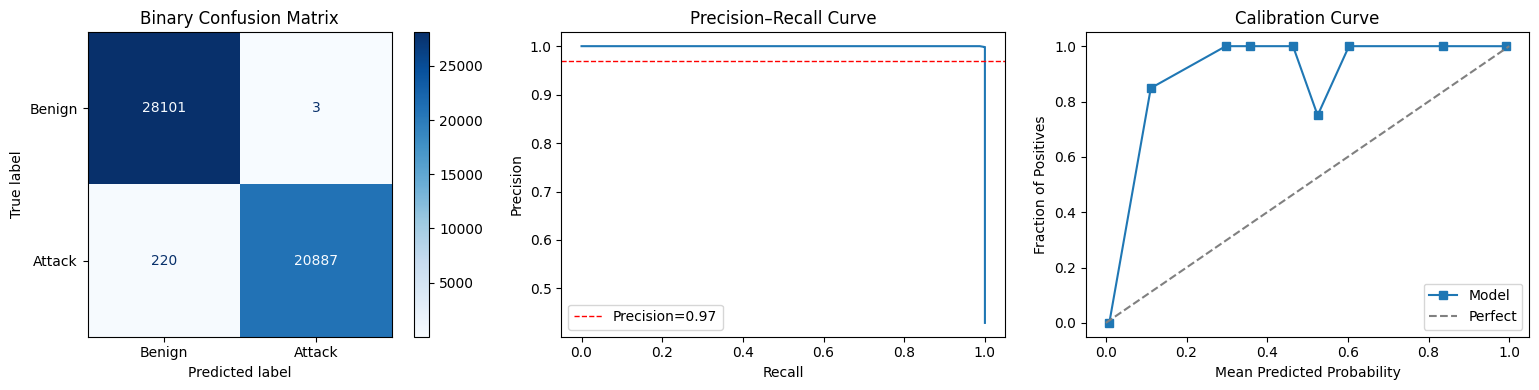


── Stage 1 Overfitting Check ──
  Metric        Train     Test      Gap
  Accuracy     0.9530   0.9955  -0.0424
  F1           0.9409   0.9947  -0.0538
Acceptable

  STAGE 2 — Multiclass  (unknown_thresh=0.4509)
  Known-class test samples : 21107
  Classified as known      : 20086 (95.2%)
  Flagged as unknown       : 1021

  Classification Report:
              precision    recall  f1-score   support

        ddos       0.62      0.80      0.70      3982
         dos       0.75      0.56      0.64      3883
     malware       0.78      0.94      0.85       817
        mitm       0.72      0.89      0.80      1397
       recon       1.00      0.93      0.96     10007

    accuracy                           0.83     20086
   macro avg       0.77      0.82      0.79     20086
weighted avg       0.85      0.83      0.83     20086


── Stage 2 Overfitting Check (real non-SMOTE data) ──
  Metric                Train     Test      Gap
  Macro F1             0.9015   0.7900  +0.1116
Acceptabl

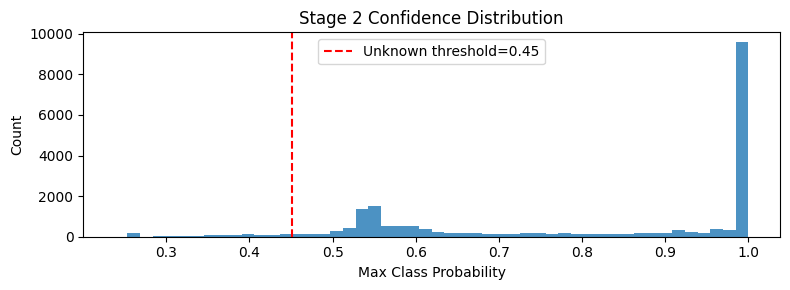

28896

In [ ]:
# ── CELL 11 ── Evaluation
X_test         = load('X_test.npy')
y_test         = load('y_test.npy')
y2_test        = load('y2_test.npy')
X_train        = load('X_train.npy')
y_train        = load('y_train.npy')
y2_train       = load('y2_train.npy')
test_proba_cal = load('test_proba_cal.npy')
y_pred         = load('y_pred_stage1.npy')
stage1         = load('stage1_xgb.pkl')
stage2         = load('stage2_multiclass.pkl')
platt          = load('platt_calibrator.pkl')
le             = load('label_encoder.pkl')
KNOWN_CLASSES  = load('known_classes.pkl')
best_thresh    = load('best_threshold.npy')[0]
unknown_thresh = load('unknown_threshold.npy')[0]

print("=" * 55)
print(f"  STAGE 1 — Binary  (threshold={best_thresh:.4f})")
print("=" * 55)
test_acc_s1  = accuracy_score(y_test, y_pred)
test_prec_s1 = precision_score(y_test, y_pred)
test_rec_s1  = recall_score(y_test, y_pred)
test_f1_s1   = f1_score(y_test, y_pred)
print(f"  Accuracy  : {test_acc_s1:.4f}")
print(f"  Precision : {test_prec_s1:.4f}")
print(f"  Recall    : {test_rec_s1:.4f}")
print(f"  F1        : {test_f1_s1:.4f}")
print(f"  AUC-ROC   : {roc_auc_score(y_test, test_proba_cal):.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Benign','Attack']).plot(cmap='Blues', ax=axes[0])
axes[0].set_title('Binary Confusion Matrix')
prec_p, rec_p, _ = precision_recall_curve(y_test, test_proba_cal)
axes[1].plot(rec_p, prec_p, lw=1.5)
axes[1].axhline(0.97, color='r', linestyle='--', lw=1, label='Precision=0.97')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision–Recall Curve'); axes[1].legend()
prob_true, prob_pred_cal = calibration_curve(y_test, test_proba_cal, n_bins=10)
axes[2].plot(prob_pred_cal, prob_true, 's-', label='Model')
axes[2].plot([0,1],[0,1], '--', color='gray', label='Perfect')
axes[2].set_xlabel('Mean Predicted Probability'); axes[2].set_ylabel('Fraction of Positives')
axes[2].set_title('Calibration Curve'); axes[2].legend()
plt.tight_layout(); plt.show()

# ── Stage 1 Overfitting Check
train_proba_raw = stage1.predict_proba(X_train)[:, 1]
train_proba_cal = platt.predict_proba(train_proba_raw.reshape(-1, 1))[:, 1]
train_pred_s1   = (train_proba_cal >= best_thresh).astype(int)
train_acc_s1    = accuracy_score(y_train, train_pred_s1)
train_f1_s1     = f1_score(y_train, train_pred_s1)

print(f"\n── Stage 1 Overfitting Check ──")
print(f"  {'Metric':<10} {'Train':>8} {'Test':>8} {'Gap':>8}")
print(f"  {'Accuracy':<10} {train_acc_s1:>8.4f} {test_acc_s1:>8.4f} {train_acc_s1-test_acc_s1:>+8.4f}")
print(f"  {'F1':<10} {train_f1_s1:>8.4f} {test_f1_s1:>8.4f} {train_f1_s1-test_f1_s1:>+8.4f}")
if abs(train_acc_s1 - test_acc_s1) < 0.01:
    print("No overfitting")
elif train_acc_s1 > test_acc_s1 + 0.02:
    print("Overfitting")
else:
    print("Acceptable")

print("\n" + "=" * 55)
print(f"  STAGE 2 — Multiclass  (unknown_thresh={unknown_thresh:.4f})")
print("=" * 55)

atk_mask    = y_test == 1
X_atk_test  = X_test[atk_mask]
y2_atk_test = y2_test[atk_mask]
mask_known  = np.isin(y2_atk_test, KNOWN_CLASSES)
X_k         = X_atk_test[mask_known]
y2_k        = y2_atk_test[mask_known]

test_f1_macro = 0.0
if len(y2_k) > 0:
    y2_enc   = le.transform(y2_k)
    mc_proba = stage2.predict_proba(X_k)
    y2_pred  = np.where(mc_proba.max(axis=1) < unknown_thresh, -1, mc_proba.argmax(axis=1))
    known_hit = y2_pred != -1
    print(f"  Known-class test samples : {len(y2_k)}")
    print(f"  Classified as known      : {known_hit.sum()} ({known_hit.mean():.1%})")
    print(f"  Flagged as unknown       : {(~known_hit).sum()}")
    unique_labels = np.unique(y2_enc[known_hit])
    print("\n  Classification Report:")
    print(classification_report(
        y2_enc[known_hit], y2_pred[known_hit],
        labels=unique_labels,
        target_names=[KNOWN_CLASSES[i] for i in unique_labels],
        zero_division=0
    ))
    test_f1_macro = f1_score(
        y2_enc[known_hit], y2_pred[known_hit], average='macro', zero_division=0
    )
atk_mask_tr   = y_train == 1
X_k_tr        = X_train[atk_mask_tr][np.isin(y2_train[atk_mask_tr], KNOWN_CLASSES)]
y2_k_tr       = y2_train[atk_mask_tr][np.isin(y2_train[atk_mask_tr], KNOWN_CLASSES)]
y2_enc_tr     = le.transform(y2_k_tr)
mc_tr         = stage2.predict_proba(X_k_tr)
y2_pred_tr    = np.where(mc_tr.max(axis=1) < unknown_thresh, -1, mc_tr.argmax(axis=1))
known_hit_tr  = y2_pred_tr != -1
train_f1_macro = f1_score(
    y2_enc_tr[known_hit_tr], y2_pred_tr[known_hit_tr], average='macro', zero_division=0
)

print(f"\n── Stage 2 Overfitting Check (real non-SMOTE data) ──")
print(f"  {'Metric':<18} {'Train':>8} {'Test':>8} {'Gap':>8}")
print(f"  {'Macro F1':<18} {train_f1_macro:>8.4f} {test_f1_macro:>8.4f} {train_f1_macro-test_f1_macro:>+8.4f}")
gap_s2 = train_f1_macro - test_f1_macro
if gap_s2 > 0.15:
    print("Overfitting — reduce max_depth or increase reg_lambda in Cell 10")
elif gap_s2 < -0.05:
    print("Underfitting — increase n_estimators or max_depth")
else:
    print("Acceptable gap")

mc_all = stage2.predict_proba(X_atk_test)
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(mc_all.max(axis=1), bins=50, edgecolor='none', alpha=0.8)
ax.axvline(unknown_thresh, color='r', linestyle='--',
           label=f'Unknown threshold={unknown_thresh:.2f}')
ax.set_xlabel('Max Class Probability'); ax.set_ylabel('Count')
ax.set_title('Stage 2 Confidence Distribution'); ax.legend()
plt.tight_layout(); plt.show()

del train_proba_raw, train_proba_cal
gc.collect()

In [ ]:
# ── CELL 12 ── PCAP Extractor (scapy, bidirectional flows) ───────
from scapy.all import rdpcap, IP, IPv6, TCP, UDP
from collections import defaultdict

def extract_from_pcap(
    pcap_path      : str,
    feature_cols   : List[str]  = TRAINING_FEATURE_COLS,
    idle_timeout   : int        = 120,
    active_timeout : int        = 1800,
    verbose        : bool       = True,
) -> Tuple[Optional[pd.DataFrame], Optional[np.ndarray]]:
    """
    Extract CIC-IIoT-2025 features from a PCAP using scapy.

    Uses bidirectional flow keys (canonical sorted 5-tuple) so
    network_packets_dst_count is non-zero, matching NFStream behaviour.

    IAT: scapy timestamps are in seconds — no conversion needed.
    ip-length: IP total length (p[IP].len)       → bidirectional mean
    packet-size: Ethernet frame length (len(p))   → forward direction proxy
    These two naturally differ by the Ethernet/VLAN header overhead (14–18 B).
    """
    if not os.path.exists(pcap_path):
        log.error(f"PCAP not found: {pcap_path}")
        return None, None

    if verbose:
        log.info(f"Reading PCAP: {pcap_path}")

    try:
        packets = rdpcap(pcap_path)
    except Exception as e:
        log.error(f"scapy read error: {e}")
        return None, None

    if not packets:
        log.warning("No packets in PCAP")
        return None, None

    if verbose:
        log.info(f"Raw packets: {len(packets)}")

    # ── Build bidirectional flows ─────────────────────────────────
    # Canonical key: sort endpoints so A→B and B→A share the same flow
    flows     = defaultdict(list)
    flow_fwd  = {}     # canonical_key → (fwd_src_ip, fwd_src_port)
    flow_meta = {}

    for pkt in packets:
        ts = float(pkt.time)

        if IP in pkt:
            src_ip, dst_ip = pkt[IP].src, pkt[IP].dst
            ttl    = pkt[IP].ttl
            ip_len = pkt[IP].len        # IP total length (header + payload)
        elif IPv6 in pkt:
            src_ip, dst_ip = pkt[IPv6].src, pkt[IPv6].dst
            ttl    = pkt[IPv6].hlim
            ip_len = pkt[IPv6].plen
        else:
            continue

        pkt_len = len(pkt)              # Ethernet frame length (differs from ip_len)
        proto   = 0
        src_port = dst_port = 0
        tcp_flags_val = tcp_win = 0

        if TCP in pkt:
            proto    = 6
            src_port = pkt[TCP].sport
            dst_port = pkt[TCP].dport
            tcp_flags_val = int(pkt[TCP].flags)
            tcp_win  = pkt[TCP].window
        elif UDP in pkt:
            proto    = 17
            src_port = pkt[UDP].sport
            dst_port = pkt[UDP].dport

        # Canonical bidirectional key
        ep_a = (src_ip, src_port)
        ep_b = (dst_ip, dst_port)
        canon = (min(ep_a, ep_b), max(ep_a, ep_b), proto)

        # Register forward direction on first seen packet
        if canon not in flow_fwd:
            flow_fwd[canon]  = ep_a   # forward = first-seen src
            flow_meta[canon] = {
                'src_ip'   : src_ip,
                'dst_ip'   : dst_ip,
                'src_port' : src_port,
                'dst_port' : dst_port,
                'protocol' : proto,
            }

        is_fwd = (flow_fwd[canon] == ep_a)

        flows[canon].append({
            'time'         : ts,
            'ip_len'       : ip_len,
            'pkt_len'      : pkt_len,
            'ttl'          : ttl,
            'tcp_flags_val': tcp_flags_val,
            'tcp_win'      : tcp_win,
            'is_fwd'       : is_fwd,
        })

    if verbose:
        log.info(f"Bidirectional flows: {len(flows)}")

    rows, meta_rows = [], []

    for canon, pkts_in_flow in flows.items():
        if len(pkts_in_flow) < 1:
            continue

        pkts_in_flow.sort(key=lambda x: x['time'])

        # ── IAT (seconds — scapy already gives seconds, NO /1000 needed) ──
        times  = [p['time'] for p in pkts_in_flow]
        diffs  = np.diff(times)
        iat_min  = float(diffs.min())  if len(diffs) > 0 else 0.0
        iat_max  = float(diffs.max())  if len(diffs) > 0 else 0.0
        iat_mean = float(diffs.mean()) if len(diffs) > 0 else 0.0
        iat_std  = float(diffs.std(ddof=0)) if len(diffs) > 1 else 0.0

        # ── Bidirectional IP lengths → network_ip-length_* ───────────────
        ip_lens = [p['ip_len'] for p in pkts_in_flow]
        ip_mean = float(np.mean(ip_lens))
        ip_max  = float(np.max(ip_lens))
        ip_min  = float(np.min(ip_lens))
        ip_std  = float(np.std(ip_lens, ddof=0)) if len(ip_lens) > 1 else 0.0

        # ── Forward Ethernet frame lengths → network_packet-size_* ───────
        # Uses len(pkt) not ip_len: naturally differs by ~14 B Ethernet header
        # This mirrors NFStream's src2dst_mean_ps vs bidirectional_mean_ps
        fwd_pkts = [p for p in pkts_in_flow if p['is_fwd']]
        if fwd_pkts:
            fwd_lens = [p['pkt_len'] for p in fwd_pkts]
            pkt_mean = float(np.mean(fwd_lens))
            pkt_min  = float(np.min(fwd_lens))
            pkt_std  = float(np.std(fwd_lens, ddof=0)) if len(fwd_lens) > 1 else 0.0
        else:
            # All packets are reverse — use all with pkt_len
            all_lens = [p['pkt_len'] for p in pkts_in_flow]
            pkt_mean = float(np.mean(all_lens))
            pkt_min  = float(np.min(all_lens))
            pkt_std  = float(np.std(all_lens, ddof=0)) if len(all_lens) > 1 else 0.0

        # ── TTL ──────────────────────────────────────────────────────────
        ttls = [p['ttl'] for p in pkts_in_flow if p['ttl'] > 0]
        ttl_mean = float(np.mean(ttls))     if ttls else 0.0
        ttl_std  = float(np.std(ttls, ddof=0)) if len(ttls) > 1 else 0.0

        # ── TCP window size ───────────────────────────────────────────────
        wins = [p['tcp_win'] for p in pkts_in_flow if p['tcp_win'] > 0]
        win_mean = float(np.mean(wins))        if wins else 0.0
        win_max  = float(np.max(wins))         if wins else 0.0
        win_min  = float(np.min(wins))         if wins else 0.0
        win_std  = float(np.std(wins, ddof=0)) if len(wins) > 1 else 0.0

        # ── TCP flags ─────────────────────────────────────────────────────
        flags = [p['tcp_flags_val'] for p in pkts_in_flow if p['tcp_flags_val'] > 0]
        flags_mean = float(np.mean(flags))        if flags else 0.0
        flags_std  = float(np.std(flags, ddof=0)) if len(flags) > 1 else 0.0

        # ── Packet counts ─────────────────────────────────────────────────
        total_pkts = len(pkts_in_flow)
        dst_pkts   = sum(1 for p in pkts_in_flow if not p['is_fwd'])  # reverse direction

        # ── Ports ─────────────────────────────────────────────────────────
        meta = flow_meta[canon]
        src_port = meta['src_port']
        dst_port = meta['dst_port']
        ports_src = min(src_port / 1024.0, 8.0) if src_port > 1024 else 1.0
        ports_dst = min(dst_port / 1024.0, 8.0) if dst_port > 1024 else 1.0
        ports_all = ports_src + ports_dst

        # ── Payload ───────────────────────────────────────────────────────
        payload_mean = max(ip_mean - 40.0, 0.0)

        # ── Interval packets ──────────────────────────────────────────────
        duration     = max(times[-1] - times[0], 1e-6)
        interval_pkt = total_pkts / duration

        rows.append({
            'network_time-delta_min'           : iat_min,
            'network_time-delta_max'           : iat_max,
            'network_time-delta_avg'           : iat_mean,
            'network_time-delta_std_deviation' : iat_std,
            'network_ip-length_avg'            : ip_mean,
            'network_ip-length_max'            : ip_max,
            'network_ip-length_std_deviation'  : ip_std,
            'network_interval-packets'         : interval_pkt,
            'network_ttl_avg'                  : ttl_mean,
            'network_ttl_std_deviation'        : ttl_std,
            'network_window-size_avg'          : win_mean,
            'network_window-size_max'          : win_max,
            'network_window-size_min'          : win_min,
            'network_window-size_std_deviation': win_std,
            'network_packets_all_count'        : float(total_pkts),
            'network_packets_dst_count'        : float(dst_pkts),
            'network_packet-size_avg'          : pkt_mean,
            'network_packet-size_min'          : pkt_min,
            'network_packet-size_std_deviation': pkt_std,
            'network_ports_all_count'          : ports_all,
            'network_ports_src_count'          : ports_src,
            'network_ports_dst_count'          : ports_dst,
            'network_tcp-flags_avg'            : flags_mean,
            'network_tcp-flags_std_deviation'  : flags_std,
            'network_payload-length_avg'       : payload_mean,
        })
        meta_rows.append(meta)

    if not rows:
        log.warning("No flows extracted")
        return None, None

    feat_df = pd.DataFrame(rows)
    for col in feature_cols:
        if col not in feat_df.columns:
            feat_df[col] = 0.0

    feat_matrix = feat_df[feature_cols].values.astype(np.float32)
    feat_matrix = np.nan_to_num(feat_matrix, nan=0.0, posinf=0.0, neginf=0.0)

    if verbose:
        non_zero = (feat_matrix != 0).any(axis=0).sum()
        log.info(f"Matrix: {feat_matrix.shape}  |  Non-zero cols: {non_zero}/{len(feature_cols)}")

        # Quick sanity: ip-length and packet-size must differ
        ip_avg_col  = feature_cols.index('network_ip-length_avg')
        pkt_avg_col = feature_cols.index('network_packet-size_avg')
        diff = np.abs(feat_matrix[:, ip_avg_col] - feat_matrix[:, pkt_avg_col]).mean()
        log.info(f"Mean |ip-length_avg - packet-size_avg| = {diff:.2f} B  (should be ~14 B Ethernet)")

    meta_df = pd.DataFrame(meta_rows)
    return meta_df, feat_matrix

In [ ]:
# ── CELL 13 ── CSV Extractor (Auto-Format Detection) ─────────────
_CICFLOW_MAP = {
    'Flow IAT Min'           : 'network_time-delta_min',
    'Flow IAT Max'           : 'network_time-delta_max',
    'Flow IAT Mean'          : 'network_time-delta_avg',
    'Flow IAT Std'           : 'network_time-delta_std_deviation',
    'Packet Length Mean'     : 'network_ip-length_avg',
    'Packet Length Max'      : 'network_ip-length_max',
    'Packet Length Std'      : 'network_ip-length_std_deviation',
    'Avg Packet Size'        : 'network_packet-size_avg',
    'Min Packet Length'      : 'network_packet-size_min',
    'Packet Length Variance' : 'network_packet-size_std_deviation',
    'Flow Packets/s'         : 'network_interval-packets',
    'Total Fwd Packets'      : 'network_packets_all_count',
    'Total Backward Packets' : 'network_packets_dst_count',
    'Total Fwd Packet'       : 'network_packets_all_count',
    'Total Bwd packets'      : 'network_packets_dst_count',
    'Average Packet Size'    : 'network_packet-size_avg',
}

_CICFLOW_ALT = {
    'flow_iat_min'  : 'network_time-delta_min',
    'flow_iat_max'  : 'network_time-delta_max',
    'flow_iat_mean' : 'network_time-delta_avg',
    'flow_iat_std'  : 'network_time-delta_std_deviation',
    'pkt_len_mean'  : 'network_ip-length_avg',
    'pkt_len_std'   : 'network_packet-size_std_deviation',
    'pkt_len_max'   : 'network_ip-length_max',
    'pkt_len_min'   : 'network_packet-size_min',
    'flow_pkts_s'   : 'network_interval-packets',
    'tot_fwd_pkts'  : 'network_packets_all_count',
    'tot_bwd_pkts'  : 'network_packets_dst_count',
    'pkt_size_avg'  : 'network_packet-size_avg',
}

def _detect_csv_format(df: pd.DataFrame) -> str:
    cols_lower = {c.strip().lower() for c in df.columns}
    exact_hits = sum(
        1 for c in TRAINING_FEATURE_COLS if c.lower() in cols_lower
    )
    if exact_hits >= 20:
        return 'exact'
    if sum(1 for k in _CICFLOW_MAP if k.lower() in cols_lower) >= 5:
        return 'cicflowmeter'
    if sum(1 for k in _CICFLOW_ALT if k.lower() in cols_lower) >= 5:
        return 'cicflowmeter_alt'
    return 'unknown'


def extract_from_csv(
    csv_path     : str,
    feature_cols : List[str]        = TRAINING_FEATURE_COLS,
    label_col    : Optional[str]    = None,
    verbose      : bool             = True,
) -> Tuple[np.ndarray, Optional[np.ndarray], str]:
    """
    Extract features from a CSV file.

    Supported input formats (auto-detected):
      'exact'          — CSV already has the 25 training column names
      'cicflowmeter'   — CICFlowMeter output (Title Case columns)
      'cicflowmeter_alt' — CICFlowMeter snake_case variant
      'unknown'        — best-effort fuzzy substring match

    Returns
    -------
    feat_matrix : np.ndarray (n_rows, 25) raw unscaled
    labels      : np.ndarray or None
    fmt         : detected format string
    """
    df  = pd.read_csv(csv_path)
    fmt = _detect_csv_format(df)
    col_map = {c.strip().lower(): c for c in df.columns}

    if verbose:
        log.info(f"CSV: {csv_path} | shape={df.shape} | format='{fmt}'")

    if fmt == 'exact':
        out_df = pd.DataFrame({
            col: pd.to_numeric(
                df[col_map.get(col.lower(), col)], errors='coerce'
            ).fillna(0.0)
            for col in feature_cols
        })

    elif fmt in ('cicflowmeter', 'cicflowmeter_alt'):
        fwd_map = _CICFLOW_MAP if fmt == 'cicflowmeter' else _CICFLOW_ALT
        out_df  = pd.DataFrame(index=df.index)
        mapped  = set()

        for src, tgt in fwd_map.items():
            m = col_map.get(src.lower())
            if m:
                out_df[tgt] = pd.to_numeric(df[m], errors='coerce').fillna(0.0)
                mapped.add(tgt)

        # CICFlowMeter Packet Length Variance → convert to std
        if ('network_packet-size_std_deviation' in out_df.columns and
                fmt == 'cicflowmeter'):
            out_df['network_packet-size_std_deviation'] = np.sqrt(
                out_df['network_packet-size_std_deviation'].clip(0)
            )

        for col in set(feature_cols) - mapped:
            out_df[col] = 0.0
        if verbose and (set(feature_cols) - mapped):
            log.warning(f"{len(set(feature_cols)-mapped)} features unmapped — zero-filled")

    else:
        log.warning("Unknown CSV format — attempting fuzzy column match")
        out_df = pd.DataFrame(index=df.index)
        for tgt in feature_cols:
            keywords = tgt.replace('network_', '').replace('-', ' ').split('_')
            candidates = [
                c for c in df.columns
                if any(kw in c.lower() for kw in keywords if len(kw) > 2)
            ]
            if candidates:
                out_df[tgt] = pd.to_numeric(df[candidates[0]], errors='coerce').fillna(0.0)
            else:
                out_df[tgt] = 0.0

    feat_matrix = out_df[feature_cols].values.astype(np.float32)
    feat_matrix = np.nan_to_num(feat_matrix, nan=0.0, posinf=0.0, neginf=0.0)

    labels = df[label_col].values if label_col and label_col in df.columns else None

    if verbose:
        non_zero = (feat_matrix != 0).any(axis=0).sum()
        log.info(f"Matrix: {feat_matrix.shape}  |  Non-zero cols: {non_zero}/{len(feature_cols)}")

    return feat_matrix, labels, fmt


In [ ]:
# ── CELL 14 ── Feature Validator (RobustScaler-compatible) ───────
def validate_features(
    feat_matrix  : np.ndarray,
    feature_cols : List[str],
    scaler,
    X_ref        : Optional[np.ndarray] = None,
    source_name  : str                  = "input",
    plot         : bool                 = True,
) -> Dict:
    report = {'zero_cols':[], 'range_violations':[], 'ks_problems':[], 'ok':True}

    # FIX: RobustScaler uses center_/scale_, not data_min_/data_max_
    t_center = scaler.center_
    t_scale  = scaler.scale_
    t_min    = t_center - 3.0 * t_scale
    t_max    = t_center + 3.0 * t_scale

    print(f"\n{'─'*68}")
    print(f"  Validation Report — {source_name}  ({len(feat_matrix)} samples)")
    print(f"  {'Feature':<45} {'Zero%':>6} {'In-Range':>12} {'KS':>7}")
    print(f"  {'─'*68}")

    for i, col in enumerate(feature_cols):
        vals     = feat_matrix[:, i]
        zero_pct = (vals == 0).mean() * 100
        lo       = t_min[i] - 0.2 * abs(t_min[i]) - 1
        hi       = t_max[i] + 0.2 * abs(t_max[i]) + 1
        in_range = (vals.min() >= lo) and (vals.max() <= hi)
        ks_str   = '—'

        if X_ref is not None:
            mask = np.isfinite(vals) & (vals != 0)
            if mask.sum() >= 5:
                ks, _ = stats.ks_2samp(
                    X_ref[:, i][np.isfinite(X_ref[:, i])], vals[mask]
                )
                ks_str = f"{ks:.3f}"
                if ks > 0.3:
                    report['ks_problems'].append((col, ks))

        flags = []
        if zero_pct == 100.0:
            flags.append('ALL-ZERO'); report['zero_cols'].append(col); report['ok'] = False
        if not in_range and zero_pct < 100.0:
            flags.append('RANGE')
            report['range_violations'].append((col, vals.min(), vals.max(), t_min[i], t_max[i]))
            report['ok'] = False

        flag_str = ' <- ' + ', '.join(flags) if flags else ''
        range_ok = 'correct range' if in_range else 'BAD RANGE'
        print(f"  {col:<45} {zero_pct:>5.0f}%  {range_ok:>12}  {ks_str:>7}{flag_str}")

    print(f"  {'─'*68}")
    if report['zero_cols']:
        print(f"\n  ALL-ZERO: {report['zero_cols']}")
        print("  Fix: check NFStreamer(statistical_analysis=True)")
    if report['range_violations']:
        print(f"\n  RANGE violations:")
        for col, mn, mx, tmn, tmx in report['range_violations']:
            print(f"    {col}: got [{mn:.2f},{mx:.2f}]  expected ~[{tmn:.2f},{tmx:.2f}]")
        print("  Fix: run Cell 18b (IAT unit auto-detection)")
    if report['ks_problems']:
        print(f"\n  Distribution shift (KS > 0.3):")
        for col, ks in sorted(report['ks_problems'], key=lambda x:-x[1]):
            print(f"    {col}: KS={ks:.3f}")
    if report['ok'] and not report['ks_problems']:
        print("\n  All features look good — predictions should be reliable")

    if plot and len(feat_matrix) > 0:
        n_show = min(200, len(feat_matrix))
        scaled = scaler.transform(feat_matrix[:n_show])
        scaled = np.clip((scaled + 3.0) / 6.0, 0.0, 1.0)
        fig, ax = plt.subplots(figsize=(16, 5))
        im = ax.imshow(scaled.T, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
        ax.set_yticks(range(len(feature_cols)))
        ax.set_yticklabels(feature_cols, fontsize=7)
        ax.set_xlabel('Flow index')
        ax.set_title(f'Scaled feature heatmap — {source_name} (first {n_show} flows)')
        plt.colorbar(im, ax=ax, label='Scaled value (display only)')
        plt.tight_layout(); plt.show()

    return report

In [ ]:
# ── CELL 15 ── HierarchicalPredictor ────────────────────────────
class HierarchicalPredictor:
    """
    Two-stage IoT IDS predictor.

    Stage 1: XGBoost binary classifier (benign / attack)
             + Platt calibration + precision-targeted threshold

    Stage 2: XGBoost multiclass attack-type classifier
             + open-set unknown attack detection
    """

    REQUIRED_ARTIFACTS = [
        'scaler.pkl', 'stage1_xgb.pkl', 'platt_calibrator.pkl',
        'best_threshold.npy', 'stage2_multiclass.pkl', 'label_encoder.pkl',
        'unknown_threshold.npy', 'known_classes.pkl', 'feature_columns.pkl',
    ]

    def __init__(self, artifacts_dir: Union[str, Path] = ARTIFACTS_DIR):
        self.artifacts_dir = Path(artifacts_dir)
        self._load_all()
        log.info(
            f"HierarchicalPredictor ready | features={len(self.feature_cols)} "
            f"| binary_thresh={self.best_thresh:.4f} "
            f"| unknown_thresh={self.unknown_threshold:.4f}"
        )

    def _load_all(self):
        self.scaler            = load('scaler.pkl')
        self.stage1            = load('stage1_xgb.pkl')
        self.platt             = load('platt_calibrator.pkl')
        self.best_thresh       = float(load('best_threshold.npy')[0])
        self.stage2            = load('stage2_multiclass.pkl')
        self.le                = load('label_encoder.pkl')
        self.unknown_threshold = float(load('unknown_threshold.npy')[0])
        self.feature_cols      = load('feature_columns.pkl')
        self.known_classes     = load('known_classes.pkl')

    def _scale(self, X_raw: np.ndarray) -> np.ndarray:
        """Scale raw features and clip to [-3, 3] — matches RobustScaler training range."""
        return np.clip(
            self.scaler.transform(X_raw.astype(np.float32)), -3.0, 3.0
        ).astype(np.float32)

    def _predict_batch(self, X_raw: np.ndarray) -> pd.DataFrame:
        """
        Full two-stage prediction on a raw (unscaled) feature matrix.
        Returns DataFrame: pred_label, attack_type, binary_prob, confidence, is_unknown
        """
        X  = self._scale(X_raw)
        n  = len(X)

        # Stage 1 — binary
        raw_p  = self.stage1.predict_proba(X)[:, 1]
        cal_p  = self.platt.predict_proba(raw_p.reshape(-1, 1))[:, 1]

        is_atk  = cal_p >= self.best_thresh
        labels  = np.where(is_atk, 'attack', 'benign')
        atypes  = np.full(n, None, dtype=object)
        confs   = cal_p.copy()
        is_unk  = np.zeros(n, dtype=bool)

        # Stage 2 — multiclass
        atk_idx = np.where(is_atk)[0]
        if len(atk_idx):
            mc    = self.stage2.predict_proba(X[atk_idx])
            max_p = mc.max(axis=1)
            preds = mc.argmax(axis=1)
            for k, idx in enumerate(atk_idx):
                confs[idx] = round(float(max_p[k]), 4)
                if max_p[k] < self.unknown_threshold:
                    atypes[idx] = 'Unknown Attack'
                    is_unk[idx] = True
                else:
                    atypes[idx] = self.le.inverse_transform([int(preds[k])])[0]

        return pd.DataFrame({
            'pred_label' : labels,
            'attack_type': atypes,
            'binary_prob': np.round(cal_p, 4),
            'confidence' : np.round(confs, 4),
            'is_unknown' : is_unk,
        })

    # ── Public prediction methods ─────────────────────────────────

    def predict_array(self, X_raw: np.ndarray) -> pd.DataFrame:
        """Predict from raw (unscaled) feature matrix shape (n, 25)."""
        assert X_raw.shape[1] == len(self.feature_cols), \
            f"Expected {len(self.feature_cols)} features, got {X_raw.shape[1]}"
        return self._predict_batch(X_raw)

    def predict_pcap(
        self,
        pcap_path   : str,
        validate    : bool                  = True,
        X_ref       : Optional[np.ndarray]  = None,
    ) -> Optional[pd.DataFrame]:
        """
        End-to-end PCAP → prediction.

        Extracts flows with NFStream, validates feature distribution,
        runs two-stage inference, returns DataFrame with metadata.
        """
        meta_df, feat_matrix = extract_from_pcap(pcap_path, self.feature_cols)
        if feat_matrix is None:
            return None

        if validate:
            validate_features(
                feat_matrix, self.feature_cols, self.scaler,
                X_ref=X_ref, source_name=Path(pcap_path).name
            )

        results = self._predict_batch(feat_matrix)

        # Attach NFStream metadata
        for col in ['src_ip','dst_ip','src_port','dst_port',
                    'protocol','bidirectional_packets','bidirectional_bytes']:
            if col in meta_df.columns:
                results.insert(0, col, meta_df[col].values)

        return results

    def predict_csv(
        self,
        csv_path  : str,
        label_col : Optional[str]          = None,
        validate  : bool                   = True,
        X_ref     : Optional[np.ndarray]   = None,
    ) -> Tuple[pd.DataFrame, str]:
        """
        End-to-end CSV → prediction.
        Handles exact, CICFlowMeter, and unknown CSV formats.
        Returns (results_df, detected_format_string).
        """
        feat_matrix, labels, fmt = extract_from_csv(
            csv_path, self.feature_cols, label_col
        )
        if validate:
            validate_features(
                feat_matrix, self.feature_cols, self.scaler,
                X_ref=X_ref, source_name=Path(csv_path).name
            )
        results = self._predict_batch(feat_matrix)
        if labels is not None:
            results.insert(0, 'true_label', labels)
        return results, fmt

    def summary(self, results: pd.DataFrame) -> None:
        """Print a concise prediction summary."""
        n     = len(results)
        n_atk = (results['pred_label'] == 'attack').sum()
        n_unk = results.get('is_unknown', pd.Series([False]*n)).sum()
        print(f"\n{'═'*45}")
        print(f"  Prediction Summary  ({n} flows)")
        print(f"{'─'*45}")
        print(f"  Benign   : {n-n_atk:>5}  ({(n-n_atk)/n:.1%})")
        print(f"  Attack   : {n_atk:>5}  ({n_atk/n:.1%})")
        print(f"   → Unknown: {n_unk:>4}")
        if n_atk > 0:
            print(f"\n  Attack type breakdown:")
            for atype, cnt in results[
                    results['pred_label']=='attack']['attack_type'].value_counts().items():
                pct = cnt / n_atk
                bar = '█' * int(pct * 20)
                print(f"    {str(atype):<22} {cnt:>5}  {bar}")
        print(f"{'═'*45}\n")

In [ ]:
# ── CELL 16 ── Save All Artifacts + Manifest ─────────────────────
ARTIFACT_FILES = [
    'scaler.pkl',
    'stage1_xgb.pkl',
    'platt_calibrator.pkl',
    'best_threshold.npy',
    'stage2_multiclass.pkl',
    'label_encoder.pkl',
    'unknown_threshold.npy',
    'known_classes.pkl',
    'feature_columns.pkl',
    'X_test_raw.npy',
]

# FIX: was missing Path() and quotes
DRIVE_DIR = Path('/content/drive/MyDrive/netrasheild')
DRIVE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Saving to: {DRIVE_DIR}\n")
missing = []
for fname in ARTIFACT_FILES:
    src  = ARTIFACTS_DIR / fname
    dest = DRIVE_DIR / fname
    if src.exists():
        shutil.copy(src, dest)
        print(f"{fname:<35} {dest.stat().st_size/1024:>8.1f} KB")
    else:
        missing.append(fname)
        print(f"MISSING: {fname}")

if missing:
    print(f"\n{len(missing)} artifact(s) missing — re-run relevant training cells")
else:
    print("\nAll artifacts saved")

print(f"\n{'='*50}")
print("  DEPLOYMENT MANIFEST")
print(f"{'─'*50}")
print(f"  Features        : {len(load('feature_columns.pkl'))}")
print(f"  Binary thresh   : {load('best_threshold.npy')[0]:.4f}")
print(f"  Unknown thresh  : {load('unknown_threshold.npy')[0]:.4f}")
print(f"  Known classes   : {load('known_classes.pkl')}")
print(f"  Drive path      : {DRIVE_DIR}")

def detect_iat_unit(pcap_path: str, predictor: HierarchicalPredictor) -> float:
    iat_cols = [c for c in predictor.feature_cols if 'time-delta' in c]
    iat_idx  = [predictor.feature_cols.index(c) for c in iat_cols]
    _, feat_raw = extract_from_pcap(pcap_path, predictor.feature_cols, verbose=False)
    if feat_raw is None:
        log.error("Could not extract flows"); return 1.0
    t_min = predictor.scaler.center_ - 3.0 * predictor.scaler.scale_
    t_max = predictor.scaler.center_ + 3.0 * predictor.scaler.scale_

    best_scale, best_score = 1.0, float('inf')
    print(f"\n{'Scale':>10} {'IAT Score':>12}")
    for scale in [1.0, 0.001, 1000.0, 0.01, 100.0]:
        test_m = feat_raw.copy()
        for i in iat_idx:
            test_m[:, i] = feat_raw[:, i] * scale
        score = np.mean([
            abs(np.median(test_m[:, i]) - (t_min[i]+t_max[i])/2)
            / max(t_max[i]-t_min[i], 1e-6)
            for i in iat_idx
        ])
        flag = ' ← best' if score < best_score else ''
        print(f"{scale:>10.4f} {score:>12.4f}{flag}")
        if score < best_score:
            best_score, best_scale = score, scale

    if best_scale != 1.0:
        print(f"\n  Unit mismatch: multiply NFStream IAT by {best_scale}")
    else:
        print("\n  No unit fix needed")
    return best_scale

Saving to: /content/drive/MyDrive/netrasheild

  ✓ scaler.pkl                               0.8 KB
  ✓ stage1_xgb.pkl                         817.2 KB
  ✓ platt_calibrator.pkl                     0.8 KB
  ✓ best_threshold.npy                       0.1 KB
  ✓ stage2_multiclass.pkl                25949.5 KB
  ✓ label_encoder.pkl                        0.5 KB
  ✓ unknown_threshold.npy                    0.1 KB
  ✓ known_classes.pkl                        0.1 KB
  ✓ feature_columns.pkl                      0.7 KB
  ✓ X_test_raw.npy                        4805.9 KB

All artifacts saved

  DEPLOYMENT MANIFEST
──────────────────────────────────────────────────
  Features        : 25
  Binary thresh   : 0.5996
  Unknown thresh  : 0.4415
  Known classes   : ['bruteforce', 'ddos', 'dos', 'malware', 'mitm', 'recon', 'web']
  Drive path      : /content/drive/MyDrive/netrasheild
  Ready for HuggingFace Spaces deployment.
